# 📈 Next-Day Stock Opening Price Prediction

## 🎯 Objective
The objective of this project is to forecast the next trading day's opening price
using historical stock data from Yahoo Finance.

## 📊 Data Source
Historical stock price data (Open, High, Low, Close, Volume)
retrieved using the yfinance API.

## 📌 Problem Type
Time-Series Regression

The model predicts tomorrow’s opening price using historical price patterns
and engineered technical indicators.

In [20]:
!pip install yfinance

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
ticker = "AAPL"   # or any stock
df = yf.download(ticker, start="2015-01-01", end="2025-01-01")

df.head()

/tmp/ipython-input-861016310.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [23]:
df = df.sort_index()

## 🛠 Feature Engineering

To improve predictive performance, several technical indicators were created:

- Lag features (previous day closing prices)
- Moving averages (5-day and 10-day)
- Rolling volatility
- Daily returns

These features help capture short-term trends, momentum, and market volatility.

In [24]:
df["Return"] = df["Close"].pct_change()

df["MA_5"] = df["Close"].rolling(5).mean()
df["MA_10"] = df["Close"].rolling(10).mean()

df["Volatility_5"] = df["Close"].rolling(5).std()

# Lag features
df["Lag_1"] = df["Close"].shift(1)
df["Lag_2"] = df["Close"].shift(2)
df["Lag_3"] = df["Close"].shift(3)

In [25]:
df["Target"] = df["Open"].shift(-1)

In [26]:
df = df.dropna()

In [27]:
X = df.drop(["Target"], axis=1)
y = df["Target"]

In [33]:
print(df[["Open", "Target"]].head())

Price            Open     Target
Ticker           AAPL           
Date                            
2015-01-15  24.363287  23.705482
2015-01-16  23.705482  23.884883
2015-01-20  23.884883  24.130730
2015-01-21  24.130730  24.420868
2015-01-22  24.420868  24.872706


In [28]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# 📈 Next-Day Stock Opening Price Prediction

## 🎯 Objective
The objective of this project is to forecast the next trading day's opening price
using historical stock data from Yahoo Finance.

## 📊 Data Source
Historical stock price data (Open, High, Low, Close, Volume)
retrieved using the yfinance API.

## 📌 Problem Type
Time-Series Regression

The model predicts tomorrow’s opening price using historical price patterns
and engineered technical indicators.

In [29]:
model = RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

Model Evaluation Metrics:
MAE  : 17.1762
RMSE : 27.3321
R2   : 0.0508
MAPE : 7.88%


## 📊 Interpretation of Results

- MAE represents the average absolute prediction error in price units.
- RMSE penalizes larger errors more heavily.
- R² indicates how well the model explains variance in opening prices.
- MAPE shows the average percentage error relative to actual price.

A lower MAE, RMSE, and MAPE indicate better predictive performance.

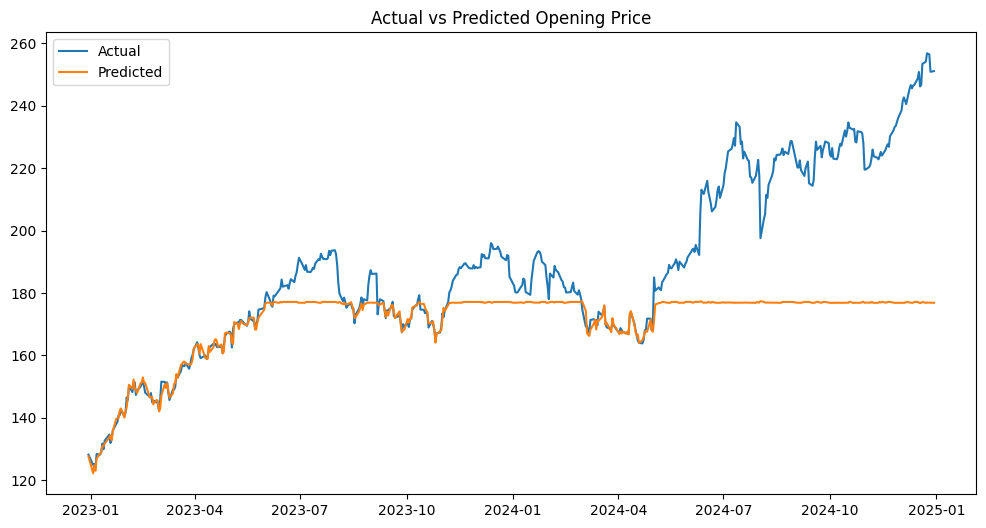

In [32]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Opening Price")
plt.show()

## ⚠️ Limitations

- Stock markets are highly volatile and influenced by external macroeconomic factors.
- The model only uses historical price data and does not include news, sentiment, or macroeconomic indicators.
- Financial time series are non-stationary, which limits long-term predictive stability.

Therefore, this model should be considered as a research or analytical tool,
not financial advice.

## ✅ Conclusion

This project demonstrates an end-to-end time-series regression workflow:

- Data collection via Yahoo Finance
- Feature engineering with lag and technical indicators
- Time-aware train-test splitting
- Model training using Random Forest
- Evaluation using MAE, RMSE, R², and MAPE

The model provides reasonable short-term predictive capability while
respecting time-series modeling best practices.

Future improvements may include:
- Walk-forward validation
- XGBoost or LSTM models
- Sentiment analysis integration